In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import genextreme as gev

from unseen import eva
from unseen import stability

import utils

In [2]:
metric = 'txx'
location = [5, 4]

var_dict = {'txx': 'tasmax', 'rx1day': 'pr'}
var = var_dict[metric]

In [3]:
def get_gev_uncertainty(da_model, reference_return_values, name):
    """Get GEV uncertainty."""

    bootstrap_samples_dict = {}
    rng = np.random.default_rng(seed=0)
    n_bootstraps = 100
    for i in range(n_bootstraps):
        boot_data = rng.choice(da_model.values, size=da_model.shape, replace=True)
        gev_params = list(eva.fit_gev(boot_data))
        return_periods, return_values = stability.return_curve(boot_data, 'gev', params=gev_params)
        diff = return_values - reference_return_values
        bootstrap_samples_dict[i] = np.abs(diff)
    df = pd.DataFrame(bootstrap_samples_dict)
    df.index = return_periods
#    df = df.drop([1.0])
    ds = df.var(axis=1)
    ds.name = name

    return ds

In [4]:
return_values_dict = {}
gev_spread_dict = {}

## AGCD

In [5]:
da_agcd = utils.get_obs_data(metric, location, dataset='AGCD-CSIRO')
da_agcd = da_agcd.sel(time=slice('1941-01-01', '2023-12-31'))

In [6]:
df_agcd = da_agcd.to_dataframe()

In [7]:
da_agcd_detrended, linear_data_agcd = utils.detrend_obs(da_agcd)

In [8]:
ranked_years_agcd = df_agcd.sort_values(by=var, ascending=False)
print(ranked_years_agcd.head(n=10))

                      lat    lon  event_time     tasmax
time                                                   
1990-06-30 00:00:00 -27.0  125.5  1990-01-02  47.657578
1993-06-30 00:00:00 -27.0  125.5  1993-01-15  47.651535
2013-06-30 00:00:00 -27.0  125.5  2013-01-10  47.639412
2020-06-30 00:00:00 -27.0  125.5  2019-12-19  47.255157
2019-06-30 00:00:00 -27.0  125.5  2019-01-14  46.910835
2011-06-30 00:00:00 -27.0  125.5  2011-01-30  46.853226
1979-06-30 00:00:00 -27.0  125.5  1979-01-03  46.673351
1998-06-30 00:00:00 -27.0  125.5  1998-01-16  46.610664
1970-06-30 00:00:00 -27.0  125.5  1970-01-21  46.353180
1989-06-30 00:00:00 -27.0  125.5  1989-02-17  46.123901


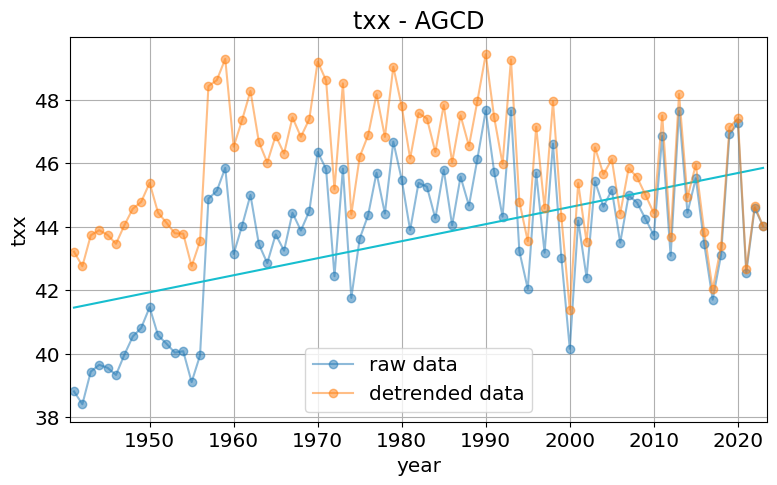

In [9]:
fig, ax = plt.subplots(figsize=[9, 5])
years = da_agcd['time'].dt.year.values
plt.plot(years, da_agcd.values, marker='o', label='raw data', color='tab:blue', alpha=0.5)
plt.plot(years, linear_data_agcd, color='tab:cyan')
plt.plot(years, da_agcd_detrended.values, marker='o', label='detrended data', color='tab:orange', alpha=0.5)
plt.xlim(years[0] - 0.5, years[-1] + 0.5)
plt.title(f'{metric} - AGCD')
plt.ylabel(metric)
plt.xlabel('year')
plt.legend()
plt.grid()

## ERA5

In [10]:
da_era = utils.get_obs_data(metric, location, dataset='ERA5')
da_era = da_era.sel(time=slice('1941-01-01', '2023-12-31'))

In [11]:
df_era = da_era.to_dataframe()

In [12]:
da_era_detrended, linear_data_era = utils.detrend_obs(da_era)

In [13]:
ranked_years_era = df_era.sort_values(by=var, ascending=False)
print(ranked_years_era.head(n=10))

                      lat    lon  event_time     tasmax
time                                                   
2013-06-30 00:00:00 -27.0  125.5  2013-01-10  46.534031
1990-06-30 00:00:00 -27.0  125.5  1990-01-02  46.441517
2011-06-30 00:00:00 -27.0  125.5  2011-01-28  46.296951
1944-06-30 00:00:00 -27.0  125.5  1944-01-22  46.129910
2019-06-30 00:00:00 -27.0  125.5  2019-01-14  46.094559
1973-06-30 00:00:00 -27.0  125.5  1973-01-01  45.765015
1998-06-30 00:00:00 -27.0  125.5  1998-01-16  45.676914
2015-06-30 00:00:00 -27.0  125.5  2014-12-09  45.117207
2020-06-30 00:00:00 -27.0  125.5  2019-12-19  45.098793
1970-06-30 00:00:00 -27.0  125.5  1970-01-21  44.939484


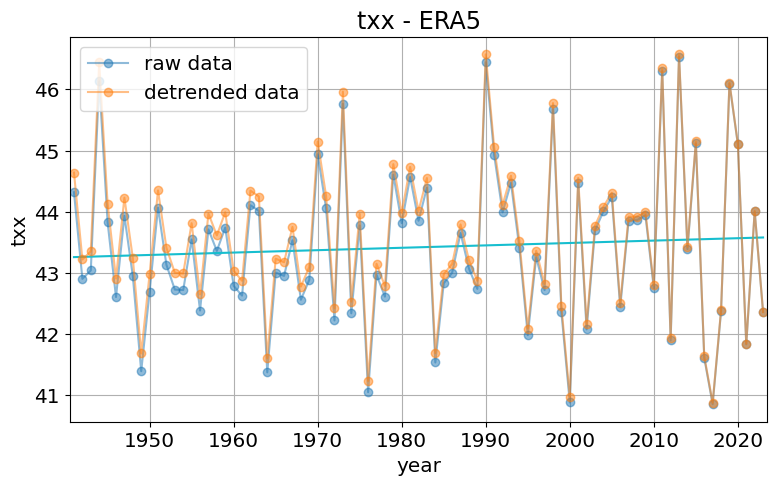

In [14]:
fig, ax = plt.subplots(figsize=[9, 5])
years = da_era['time'].dt.year.values
plt.plot(years, da_era.values, marker='o', label='raw data', color='tab:blue', alpha=0.5)
plt.plot(years, linear_data_era, color='tab:cyan')
plt.plot(years, da_era_detrended.values, marker='o', label='detrended data', color='tab:orange', alpha=0.5)
plt.xlim(years[0] - 0.5, years[-1] + 0.5)
plt.title(f'{metric} - ERA5')
plt.ylabel(metric)
plt.xlabel('year')
plt.legend()
plt.grid()

## Comparison

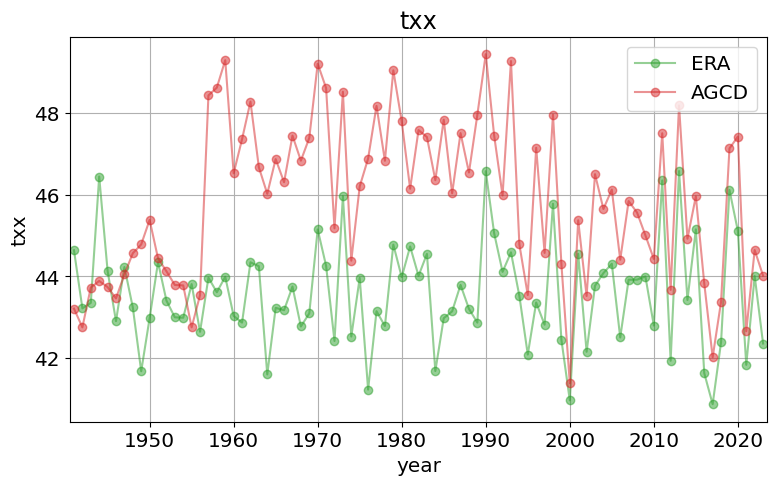

In [15]:
fig, ax = plt.subplots(figsize=[9, 5])
years = da_era['time'].dt.year.values
plt.plot(years, da_era_detrended.values, marker='o', label='ERA', color='tab:green', alpha=0.5)
plt.plot(years, da_agcd_detrended.values, marker='o', label='AGCD', color='tab:red', alpha=0.5)
plt.xlim(years[0] - 0.5, years[-1] + 0.5)
plt.title(metric)
plt.ylabel(metric)
plt.xlabel('year')
plt.legend()
plt.grid()

In [16]:
mean_era = float(da_era_detrended.mean())
mean_agcd = float(da_agcd_detrended.mean())
mean_obs = (mean_era + mean_agcd) / 2.0

In [17]:
da_era_detrended_corrected = (da_era_detrended - mean_era) + mean_obs
da_agcd_detrended_corrected = (da_agcd_detrended - mean_agcd) + mean_obs

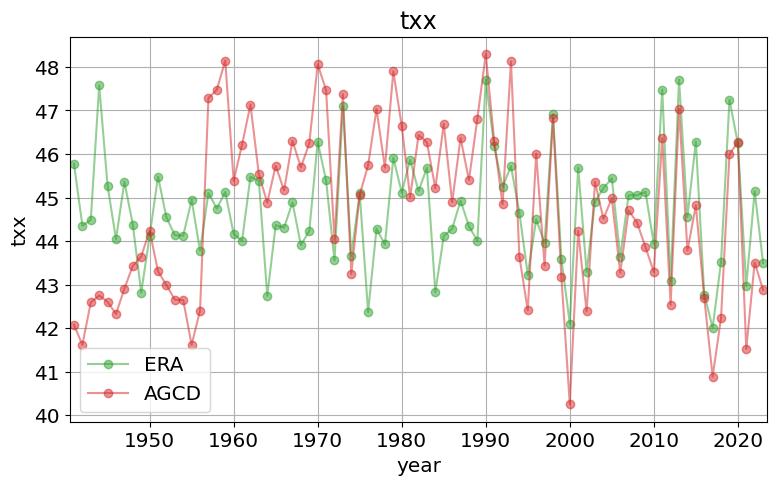

In [18]:
fig, ax = plt.subplots(figsize=[9, 5])
years = da_era['time'].dt.year.values
plt.plot(years, da_era_detrended_corrected.values, marker='o', label='ERA', color='tab:green', alpha=0.5)
plt.plot(years, da_agcd_detrended_corrected.values, marker='o', label='AGCD', color='tab:red', alpha=0.5)
plt.xlim(years[0] - 0.5, years[-1] + 0.5)
plt.title(metric)
plt.ylabel(metric)
plt.xlabel('year')
plt.legend()
plt.grid()

In [19]:
gev_shape_era_detrended, gev_loc_era_detrended, gev_scale_era_detrended = eva.fit_gev(da_era_detrended_corrected.values)
return_periods, return_values_era = stability.return_curve(
    da_era_detrended_corrected,
    'gev',
    params=[gev_shape_era_detrended, gev_loc_era_detrended, gev_scale_era_detrended],
)
return_values_dict['ERA5'] = return_values_era

gev_spread_era = get_gev_uncertainty(
    da_era_detrended_corrected,
    return_values_era,
    name='ERA5',
)
gev_spread_dict['ERA5'] = gev_spread_era

In [20]:
gev_shape_agcd_detrended, gev_loc_agcd_detrended, gev_scale_agcd_detrended = eva.fit_gev(da_agcd_detrended_corrected.values)
return_periods, return_values_agcd = stability.return_curve(
    da_agcd_detrended_corrected,
    'gev',
    params=[gev_shape_agcd_detrended, gev_loc_agcd_detrended, gev_scale_agcd_detrended],
)
return_values_dict['AGCD'] = return_values_agcd

gev_spread_agcd = get_gev_uncertainty(
    da_agcd_detrended_corrected,
    return_values_agcd,
    name='AGCD',
)
gev_spread_dict['AGCD'] = gev_spread_agcd

In [21]:
return_values_df = pd.DataFrame(return_values_dict)
return_values_df.index = return_periods
return_values_df = return_values_df.drop([1.0])

gev_spread_df = pd.DataFrame(gev_spread_dict)
gev_spread_df.index = return_periods
gev_spread_df = gev_spread_df.drop([1.0])

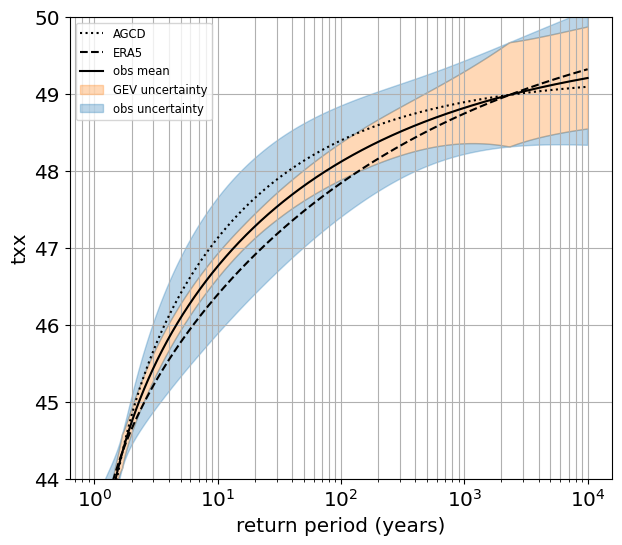

In [24]:
gev_spread = gev_spread_df.mean(axis=1)
G2 = gev_spread
G = np.sqrt(G2)

model_spread = return_values_df.var(axis=1)
M2 = model_spread
M = np.sqrt(M2)
    
T2 = G2 + M2
T = np.sqrt(T2)
F = (G + M) / T

ave_model = return_values_df.mean(axis=1)
gev_spread_upper = ave_model + (1.654 * (G / F))
gev_spread_lower = ave_model - (1.654 * (G / F))
model_spread_upper = ave_model + (1.654 * ((G + M) / F))
model_spread_lower = ave_model - (1.654 * ((G + M) / F))

return_periods = return_values_df.index.values
fig = plt.figure(figsize=[7, 6])
ax = fig.add_subplot(111)
    
ax.plot(return_periods, return_values_df['AGCD'].values, label='AGCD', color='black', linestyle=':')
ax.plot(return_periods, return_values_df['ERA5'].values, label='ERA5', color='black', linestyle='dashed')
    
ax.plot(return_periods, ave_model.values, label='obs mean', color='black')
ax.fill_between(return_periods, ave_model.values, gev_spread_upper.values, label='GEV uncertainty', color='tab:orange', alpha=0.3)
ax.fill_between(return_periods, gev_spread_lower.values, ave_model.values, color='tab:orange', alpha=0.3)
ax.fill_between(return_periods, gev_spread_upper.values, model_spread_upper.values, label='obs uncertainty', color='tab:blue', alpha=0.3)
ax.fill_between(return_periods, model_spread_lower.values, gev_spread_lower.values, color='tab:blue', alpha=0.3)

ax.legend(fontsize='small')
ax.set_xscale('log')
ax.set_xlabel('return period (years)')
ax.set_ylabel(f'{metric}')
ax.set_ylim([44, 50])
ax.grid(which='both')

plt.show()